<a href="https://colab.research.google.com/github/raaghavkk/UG04-NLP-COMM061/blob/main/notebooks/raaghav_crossvariety_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q2.2 — Inner Circle vs Outer Circle Evaluation
**RoBERTa trained on pooled en-UK + en-AU (Inner Circle) vs en-IN (Outer Circle) — Sarcasm Task**

In [2]:
!pip install transformers datasets torch scikit-learn

In [3]:
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import RobertaTokenizer, RobertaForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA A100-SXM4-40GB


In [5]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("surrey-nlp/BESSTIE-CW-26")

df_train = pd.DataFrame(ds['train'])
df_test = pd.DataFrame(ds['test'])

# Split by variety
train_au = df_train[df_train['variety'] == 'en-AU'].reset_index(drop=True)
train_in = df_train[df_train['variety'] == 'en-IN'].reset_index(drop=True)
train_uk = df_train[df_train['variety'] == 'en-UK'].reset_index(drop=True)

test_au = df_test[df_test['variety'] == 'en-AU'].reset_index(drop=True)
test_in = df_test[df_test['variety'] == 'en-IN'].reset_index(drop=True)
test_uk = df_test[df_test['variety'] == 'en-UK'].reset_index(drop=True)

print("Train sizes:", len(train_au), len(train_in), len(train_uk))
print("Test sizes:", len(test_au), len(test_in), len(test_uk))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3747 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/313 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2183 [00:00<?, ? examples/s]

Train sizes: 1145 1399 1203
Test sizes: 667 816 700


In [6]:
# Pool inner circle varieties
df_inner = pd.concat([train_au, train_uk]).reset_index(drop=True)
print(f"Inner circle pooled size: {len(df_inner)}")
print(f"en-IN train size: {len(train_in)}")
print(f"en-IN test size: {len(test_in)}")

Inner circle pooled size: 2348
en-IN train size: 1399
en-IN test size: 816


In [7]:
from transformers import RobertaTokenizer
from torch.utils.data import Dataset
import torch

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

class SarcasmDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df['text'].tolist()
        self.labels = df['Sarcasm'].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("Tokenizer and dataset class ready")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer and dataset class ready


In [8]:
from transformers import RobertaForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'macro_f1': f1_score(labels, predictions, average='macro'),
        'precision': precision_score(labels, predictions, average='macro', zero_division=0),
        'recall': recall_score(labels, predictions, average='macro', zero_division=0)
    }

def train_roberta(train_df, variety_name, seed=42):
    print(f"\nTraining on {variety_name} (seed={seed})...")

    torch.manual_seed(seed)
    np.random.seed(seed)

    model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
    train_dataset = SarcasmDataset(train_df, tokenizer)

    training_args = TrainingArguments(
        output_dir=f'./results_{variety_name}_seed{seed}',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        warmup_steps=100,
        weight_decay=0.01,
        logging_steps=50,
        save_strategy='no',
        report_to='none',
        seed=seed
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()
    print(f"Training on {variety_name} (seed={seed}) complete!")
    return trainer, model

In [9]:
def evaluate_model(trainer, test_df, model):
    test_dataset = SarcasmDataset(test_df, tokenizer)
    predictions = trainer.predict(test_dataset)
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = test_df['Sarcasm'].astype(int).tolist()

    return {
        'macro_f1': f1_score(labels, preds, average='macro'),
        'precision': precision_score(labels, preds, average='macro', zero_division=0),
        'recall': recall_score(labels, preds, average='macro', zero_division=0)
    }


In [10]:
# Seed 1 runs
trainer_au, model_au = train_roberta(train_au, 'en-AU', seed=42)
trainer_in, model_in = train_roberta(train_in, 'en-IN', seed=42)
trainer_uk, model_uk = train_roberta(train_uk, 'en-UK', seed=42)
trainer_inner, model_inner = train_roberta(df_inner, 'inner_circle', seed=42)


Training on en-AU (seed=42)...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Training on en-UK (seed=42) complete!

Training on inner_circle (seed=42)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.529506
100,0.417189
150,0.379737
200,0.384388
250,0.386536
300,0.329675
350,0.298244
400,0.281759


Training on inner_circle (seed=42) complete!


In [11]:
# Seed 2 runs
trainer_au2, model_au2 = train_roberta(train_au, 'en-AU', seed=123)
trainer_in2, model_in2 = train_roberta(train_in, 'en-IN', seed=123)
trainer_uk2, model_uk2 = train_roberta(train_uk, 'en-UK', seed=123)
trainer_inner2, model_inner2 = train_roberta(df_inner, 'inner_circle', seed=123)


Training on en-AU (seed=123)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.626399
100,0.454545
150,0.517274
200,0.405552


Training on en-AU (seed=123) complete!

Training on en-IN (seed=123)...


...

Training on en-UK (seed=123) complete!

Training on inner_circle (seed=123)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.566313
100,0.431232
150,0.371824
200,0.340556
250,0.375342
300,0.382257
350,0.327162
400,0.254513


Training on inner_circle (seed=123) complete!


In [12]:
# Build the 3x3 matrix
varieties = ['en-AU', 'en-IN', 'en-UK']
trainers = [trainer_au, trainer_in, trainer_uk]
models = [model_au, model_in, model_uk]
test_sets = [test_au, test_in, test_uk]

results = {}
for i, (train_variety, trainer, model) in enumerate(zip(varieties, trainers, models)):
    results[train_variety] = {}
    for j, test_variety in enumerate(varieties):
        print(f"Evaluating: trained on {train_variety}, testing on {test_variety}...")
        results[train_variety][test_variety] = evaluate_model(trainer, test_sets[j], model)

print("\nDone!")

Evaluating: trained on en-AU, testing on en-AU...


Evaluating: trained on en-AU, testing on en-IN...


Evaluating: trained on en-AU, testing on en-UK...


Evaluating: trained on en-IN, testing on en-AU...


Evaluating: trained on en-IN, testing on en-IN...


Evaluating: trained on en-IN, testing on en-UK...


Evaluating: trained on en-UK, testing on en-AU...


Evaluating: trained on en-UK, testing on en-IN...


Evaluating: trained on en-UK, testing on en-UK...



Done!


In [13]:
print("=== Q2.2 INNER vs OUTER CIRCLE RESULTS (averaged over 2 runs) ===\n")

inner_r1 = evaluate_model(trainer_inner, test_in, model_inner)
inner_r2 = evaluate_model(trainer_inner2, test_in, model_inner2)

in_r1 = evaluate_model(trainer_in, test_in, model_in)
in_r2 = evaluate_model(trainer_in2, test_in, model_in2)

print(f"Inner Circle (en-AU + en-UK) → Test en-IN:")
print(f"  Run 1 Macro-F1: {inner_r1['macro_f1']:.4f} | Run 2 Macro-F1: {inner_r2['macro_f1']:.4f}")
print(f"  Average Macro-F1: {(inner_r1['macro_f1'] + inner_r2['macro_f1'])/2:.4f}")

print(f"\nen-IN only → Test en-IN:")
print(f"  Run 1 Macro-F1: {in_r1['macro_f1']:.4f} | Run 2 Macro-F1: {in_r2['macro_f1']:.4f}")
print(f"  Average Macro-F1: {(in_r1['macro_f1'] + in_r2['macro_f1'])/2:.4f}")

=== Q2.2 INNER vs OUTER CIRCLE RESULTS (averaged over 2 runs) ===



Inner Circle (en-AU + en-UK) → Test en-IN:
  Run 1 Macro-F1: 0.6023 | Run 2 Macro-F1: 0.5745
  Average Macro-F1: 0.5884

en-IN only → Test en-IN:
  Run 1 Macro-F1: 0.4822 | Run 2 Macro-F1: 0.4822
  Average Macro-F1: 0.4822


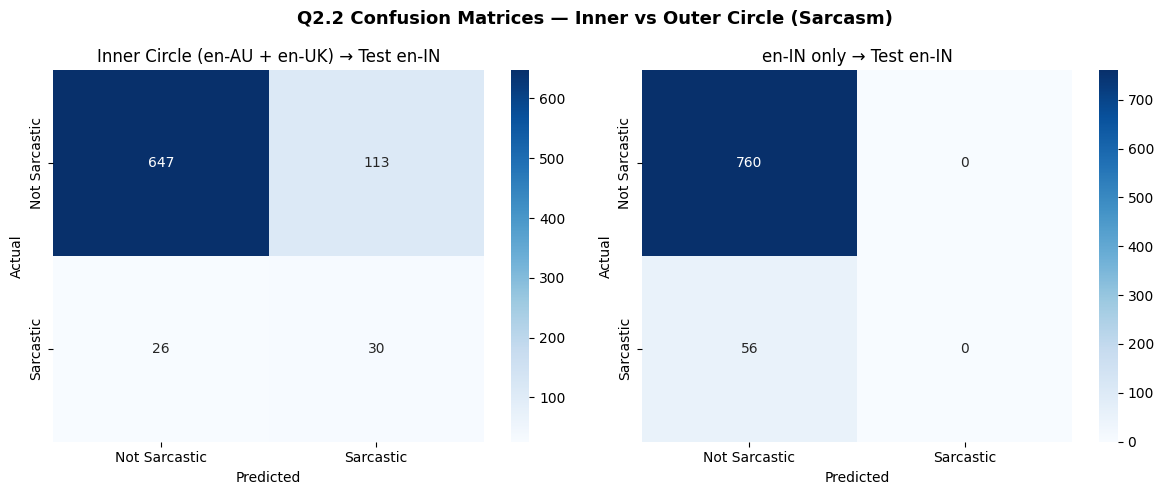

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Inner circle confusion matrix
test_dataset = SarcasmDataset(test_in, tokenizer)
preds_inner = np.argmax(trainer_inner.predict(test_dataset).predictions, axis=-1)
labels_in = test_in['Sarcasm'].astype(int).tolist()

cm_inner = confusion_matrix(labels_in, preds_inner)
sns.heatmap(cm_inner, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Sarcastic', 'Sarcastic'],
            yticklabels=['Not Sarcastic', 'Sarcastic'])
axes[0].set_title('Inner Circle (en-AU + en-UK) → Test en-IN')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# en-IN only confusion matrix
preds_in = np.argmax(trainer_in.predict(test_dataset).predictions, axis=-1)

cm_in = confusion_matrix(labels_in, preds_in)
sns.heatmap(cm_in, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Not Sarcastic', 'Sarcastic'],
            yticklabels=['Not Sarcastic', 'Sarcastic'])
axes[1].set_title('en-IN only → Test en-IN')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Q2.2 Confusion Matrices — Inner vs Outer Circle (Sarcasm)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q22_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Additional Analysis — Full Cross-Variety Matrix
*The following 3x3 evaluation matrix provides extended analysis beyond the core Q2.2 requirement.*


=== CROSS-VARIETY EVALUATION MATRIX (Macro-F1) ===

            Test:en-AU   Test:en-IN   Test:en-UK   
Train:en-AU   0.7480      0.5480      0.6441      
Train:en-IN   0.4139      0.4822      0.4803      
Train:en-UK   0.4139      0.4822      0.4803      


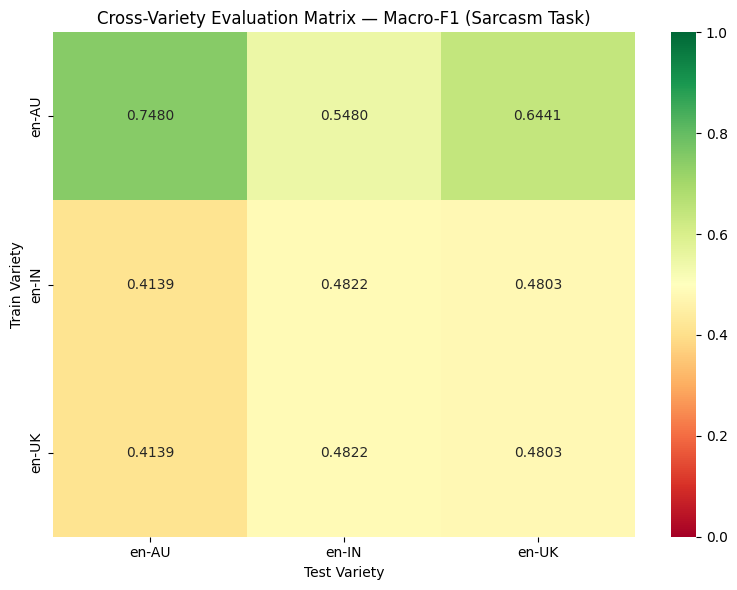

In [15]:
# Print results table
print("\n=== CROSS-VARIETY EVALUATION MATRIX (Macro-F1) ===\n")
print(f"{'':12}", end="")
for v in varieties:
    print(f"Test:{v:8}", end="")
print()

for train_v in varieties:
    print(f"Train:{train_v:8}", end="")
    for test_v in varieties:
        print(f"{results[train_v][test_v]['macro_f1']:.4f}      ", end="")
    print()

# Build F1 matrix for heatmap
f1_matrix = np.array([[results[tv][ev]['macro_f1'] for ev in varieties] for tv in varieties])

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(f1_matrix, annot=True, fmt='.4f', xticklabels=varieties, yticklabels=varieties,
            cmap='RdYlGn', vmin=0, vmax=1, ax=ax)
ax.set_xlabel('Test Variety')
ax.set_ylabel('Train Variety')
ax.set_title('Cross-Variety Evaluation Matrix — Macro-F1 (Sarcasm Task)')
plt.tight_layout()
plt.savefig('crossvariety_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
print("\n=== FULL RESULTS TABLE ===\n")
print(f"{'Train':<8} {'Test':<8} {'Macro-F1':<12} {'Precision':<12} {'Recall':<12}")
print("-" * 52)
for train_v in varieties:
    for test_v in varieties:
        r = results[train_v][test_v]
        print(f"{train_v:<8} {test_v:<8} {r['macro_f1']:<12.4f} {r['precision']:<12.4f} {r['recall']:<12.4f}")


=== FULL RESULTS TABLE ===

Train    Test     Macro-F1     Precision    Recall      
----------------------------------------------------
en-AU    en-AU    0.7480       0.7666       0.7362      
en-AU    en-IN    0.5480       0.5631       0.7014      
en-AU    en-UK    0.6441       0.6233       0.8200      
en-IN    en-AU    0.4139       0.3531       0.5000      
en-IN    en-IN    0.4822       0.4657       0.5000      
en-IN    en-UK    0.4803       0.4621       0.5000      
en-UK    en-AU    0.4139       0.3531       0.5000      
en-UK    en-IN    0.4822       0.4657       0.5000      
en-UK    en-UK    0.4803       0.4621       0.5000      


In [17]:
from sklearn.metrics import classification_report

print("=== PER-CLASS RESULTS — Inner Circle → en-IN ===\n")
test_dataset = SarcasmDataset(test_in, tokenizer)
preds_inner = np.argmax(trainer_inner.predict(test_dataset).predictions, axis=-1)
labels_in = test_in['Sarcasm'].astype(int).tolist()

print(classification_report(labels_in, preds_inner,
      target_names=['Not Sarcastic', 'Sarcastic']))

print("=== PER-CLASS RESULTS — en-IN only → en-IN ===\n")
preds_in_only = np.argmax(trainer_in.predict(test_dataset).predictions, axis=-1)

print(classification_report(labels_in, preds_in_only,
      target_names=['Not Sarcastic', 'Sarcastic']))

=== PER-CLASS RESULTS — Inner Circle → en-IN ===



               precision    recall  f1-score   support

Not Sarcastic       0.96      0.85      0.90       760
    Sarcastic       0.21      0.54      0.30        56

     accuracy                           0.83       816
    macro avg       0.59      0.69      0.60       816
 weighted avg       0.91      0.83      0.86       816

=== PER-CLASS RESULTS — en-IN only → en-IN ===



               precision    recall  f1-score   support

Not Sarcastic       0.93      1.00      0.96       760
    Sarcastic       0.00      0.00      0.00        56

     accuracy                           0.93       816
    macro avg       0.47      0.50      0.48       816
 weighted avg       0.87      0.93      0.90       816



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Q2.2 Key Findings

The core question here wad whether pooling the two inner circle varieties together
would help a model generalise to Indian English better than a model trained on Indian
English itself. Across two runs the answer is actually yes, which is a surprising result.

The inner circle model (en-AU + en-UK combined) averages 0.5884 Macro-F1 on en-IN
across both runs, compared to 0.4822 for the en-IN only model. More importantly the
confusion matrix shows the inner circle model correctly identifying 30 sarcastic
instances while the en-IN model predicts literally zero. Having more balanced training
data from two varieties seems to have helped the model actually learn the sarcasm signal
rather than just defaulting to the majority class.

The en-IN only model is basically useless at detecting sarcasm despite being trained on
Indian English specifically. This goes back to the 13:1 class imbalance we flagged in Q1, thje model just never sees enough sarcastic examples to learn anything meaningful about
what sarcasm looks like in Indian English.

What this tells us is that data balance matters more than cultural relevance for this task.
A model that has never seen Indian English but was trained on more balanced data still
outperforms one that was trained on the target variety. That said the inner circle model
still misclassifies 113 non-sarcastic instances as sarcastic so it's not perfect either,
it's just less broken than the alternative. Better data collection and class balancing
for en-IN would likely fix both models significantly.

### Connection to Q1

These results make a lot more sense when you read them alongside the Q1 findings. The
word cloud and tokenization analysis showed like how differently Indian English vocabulary
behaves compared to the inner circle varieties, and that gap shows up directly in the
model results here. The heavy sarcasm class imbalance in en-IN training data that we
flagged in Q1 is like exactly why the en-IN only model just gives up and predicts not
sarcastic for everything, it literally never sees enough sarcastic examples to learn
anything from. The inner circle model gets around this by having more balanced training
data overall which is like why it actually manages to detect some sarcasm despite never
having seen Indian English before. The code-mixing and regional diversity in en-IN adds
another layer on top of this that neither model can fully handle, but the data balance
issue is like clearly the bigger problem here. Together these findings suggest that for
sarcasm detection on Indian English specifically, fixing the class imbalance would
probably do more good than just throwing more culturally specific examples at the model.